In [1]:
# =========================================
# 06A_doi_level_regression.ipynb
# DOI-level regression
# =========================================
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, mean_squared_error
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)

WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

DOI_TABLE_FILE = os.path.join(WORK_DIR, "interim", "05B_doi_table.parquet")
DOI_X_FILE = os.path.join(WORK_DIR, "interim", "05B_doi_X.parquet")
DOI_Y_FILE = os.path.join(WORK_DIR, "interim", "05B_doi_y.parquet")
DOI_G_FILE = os.path.join(WORK_DIR, "interim", "05B_doi_groups.parquet")

REPORT_DIR = os.path.join(WORK_DIR, "reports")
META_DIR = os.path.join(WORK_DIR, "metadata")
ARTIFACT_DIR = os.path.join(WORK_DIR, "artifacts", "06A_doi_regression")

for p in [REPORT_DIR, META_DIR, ARTIFACT_DIR]:
    os.makedirs(p, exist_ok=True)

print("DOI_X_FILE:", DOI_X_FILE)

DOI_X_FILE: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\05B_doi_X.parquet


In [2]:
doi_table = pd.read_parquet(DOI_TABLE_FILE)
X = pd.read_parquet(DOI_X_FILE)
y = pd.read_parquet(DOI_Y_FILE)["T80_log1p"].copy()
groups = pd.read_parquet(DOI_G_FILE)["Ref_DOI_number"].copy()

assert len(X) == len(y) == len(groups)

print("doi_table shape:", doi_table.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("unique DOI:", groups.nunique())
X.head(2)

doi_table shape: (964, 82)
X shape: (964, 79)
y shape: (964,)
unique DOI: 964


,is_nip,is_pin,is_other_arch,etl_has_tio2,etl_has_sno2,etl_has_pcbm,etl_has_c60,etl_has_zno,htl_has_spiro,htl_has_ptaa,htl_has_pedot,htl_has_niox,htl_has_p3ht,back_has_au,back_has_ag,back_has_al,back_has_carbon,has_perovskite_additives,has_etl_additives,has_htl_additives,band_gap_ev,perovskite_thickness_nm,etl_thickness_nm,cell_area_measured_cm2,n_cells_per_substrate,encapsulation_flag,protocol_has_l,protocol_has_d,bias_is_mpp,bias_is_oc,bias_is_sc,light_intensity_suns,is_dark_condition,is_approx_1sun,is_high_light,temperature_c,rh_pct,is_room_temperature,is_hot_test,is_dry_condition,is_humid_condition,architecture_family_nip,architecture_family_other_or_unknown,architecture_family_pin,etl_family_c60,etl_family_other_or_unknown,etl_family_other_rare,etl_family_pcbm,etl_family_sno2,etl_family_tio2,etl_family_zno,htl_family_missing,htl_family_niox,htl_family_other_or_unknown,htl_family_other_rare,htl_family_p3ht,htl_family_pedot_pss,htl_family_ptaa,htl_family_spiro_ometad,backcontact_family_ag,backcontact_family_al,backcontact_family_au,backcontact_family_carbon,backcontact_family_cu,backcontact_family_other_rare,protocol_family_isos_d,protocol_family_isos_l,protocol_family_other_isos,protocol_family_other_or_unknown,protocol_family_other_rare,bias_family_mpp,bias_family_open_circuit,bias_family_other_rare,light_bin_dark_or_zero,light_bin_high_light,light_bin_missing,light_bin_other_rare,publication_year,n_devices_in_doi
0,1.0,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.55,250.0,100.0,0.10,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,27.0,30.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,1.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.5,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2016.0,2
1,1.0,0.0,0.0,0.0,0.666667,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.59,NaN,NaN,0.09,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,20.0,70.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2016.0,3


In [3]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_predictions(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "medae": median_absolute_error(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "n_test": len(y_true),
    }

def summarize_scores(df_scores, split_name, model_name):
    out = {"split": split_name, "model": model_name, "n_runs": len(df_scores)}
    for m in ["r2", "mae", "medae", "rmse", "n_test"]:
        out[f"{m}_mean"] = df_scores[m].mean()
        out[f"{m}_std"] = df_scores[m].std(ddof=1) if len(df_scores) > 1 else 0.0
    return out

In [4]:
models = {
    "elasticnet": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=SEED))
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
            random_state=SEED
        ))
    ]),
    "hist_gbrt": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=6,
            max_iter=400,
            min_samples_leaf=5,
            random_state=SEED
        ))
    ]),
}

print("Models:", list(models.keys()))

Models: ['elasticnet', 'random_forest', 'hist_gbrt']


In [5]:
from sklearn.model_selection import GroupKFold

def run_repeated_kfold_regression(
    X,
    y,
    groups,
    models,
    n_splits=5,
    n_repeats=10,
    seed=42
):
    all_scores = []
    fitted_examples = {}

    gkf = GroupKFold(n_splits=n_splits)

    for repeat in range(n_repeats):
        for fold_id, (train_idx, test_idx) in enumerate(
            gkf.split(X, y, groups=groups), start=1
        ):
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            for model_name, model in models.items():
                t0 = time.time()
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

                metrics = evaluate_predictions(y_test, y_pred)
                metrics["split"] = "doi_grouped_kfold"
                metrics["model"] = model_name
                metrics["fold_id"] = fold_id
                metrics["repeat"] = repeat
                metrics["fit_seconds"] = time.time() - t0

                all_scores.append(metrics)

                fitted_examples[model_name] = {
                    "y_true": np.array(y_test),
                    "y_pred": np.array(y_pred)
                }

    return pd.DataFrame(all_scores), fitted_examples

In [6]:
rkf_scores, rkf_examples = run_repeated_kfold_regression(
    X=X,
    y=y,
    groups=groups,
    models=models,
    n_splits=5,
    n_repeats=10,
    seed=SEED
)

rkf_summary_rows = []
for model_name in rkf_scores["model"].unique():
    dfm = rkf_scores[rkf_scores["model"] == model_name].copy()
    rkf_summary_rows.append(
        summarize_scores(dfm, "doi_grouped_kfold", model_name)
    )

rkf_summary = pd.DataFrame(rkf_summary_rows).sort_values("r2_mean", ascending=False)
rkf_summary

,split,model,n_runs,r2_mean,r2_std,mae_mean,mae_std,medae_mean,medae_std,rmse_mean,rmse_std,n_test_mean,n_test_std
1,doi_grouped_kfold,random_forest,50,0.177733,0.024326,1.236421,0.063688,0.980794,0.052242,1.576633,0.085361,192.8,0.404061
0,doi_grouped_kfold,elasticnet,50,0.149844,0.017155,1.236892,0.067215,0.988787,0.087852,1.603281,0.086633,192.8,0.404061
2,doi_grouped_kfold,hist_gbrt,50,0.063235,0.045388,1.315996,0.040340,1.082506,0.033235,1.680919,0.061373,192.8,0.404061


In [7]:
chrono_scores = None
chrono_summary = None
chrono_example = None

if "publication_year" in doi_table.columns:
    year_series = pd.to_numeric(
        doi_table["publication_year"],
        errors="coerce"
    )

    valid_mask = year_series.notna()

    doi_table_valid = doi_table.loc[valid_mask].copy()
    X_valid = X.loc[valid_mask].copy()
    y_valid = y.loc[valid_mask].copy()
    year_valid = year_series.loc[valid_mask].copy()

    # Correct chronological split
    cutoff = 2019

    train_mask = year_valid <= cutoff
    test_mask = year_valid >= 2020

    print("Chronological split:")
    print("Training years <= 2019")
    print("Test years >= 2020")
    print("Train rows:", int(train_mask.sum()))
    print("Test rows:", int(test_mask.sum()))

    rows = []
    chrono_example = {}

    for model_name, model in models.items():

        X_train = X_valid.loc[train_mask]
        X_test = X_valid.loc[test_mask]

        y_train = y_valid.loc[train_mask]
        y_test = y_valid.loc[test_mask]

        if len(X_train) > 0 and len(X_test) > 0:

            t0 = time.time()

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            metrics = evaluate_predictions(
                y_test,
                y_pred
            )

            metrics["split"] = "doi_chronological_holdout"
            metrics["model"] = model_name
            metrics["fit_seconds"] = time.time() - t0

            rows.append(metrics)

            chrono_example[model_name] = {
                "y_true": np.array(y_test),
                "y_pred": np.array(y_pred)
            }

    chrono_scores = pd.DataFrame(rows)

    if not chrono_scores.empty:
        chrono_summary = chrono_scores.sort_values(
            "r2",
            ascending=False
        )

chrono_summary

Chronological split:
Training years <= 2019
Test years >= 2020
Train rows: 917
Test rows: 47


,r2,mae,medae,rmse,n_test,split,model,fit_seconds
1,-0.010333,1.110125,0.917769,1.368893,47,doi_chronological_holdout,random_forest,2.504400
0,-0.079667,1.117878,0.974326,1.415083,47,doi_chronological_holdout,elasticnet,0.049635
2,-0.174658,1.144817,0.908276,1.476022,47,doi_chronological_holdout,hist_gbrt,2.428839


In [8]:
rkf_scores.to_csv(os.path.join(REPORT_DIR, "06A_doi_regression_rkf_all_scores.csv"), index=False)
rkf_summary.to_csv(os.path.join(REPORT_DIR, "06A_doi_regression_rkf_summary.csv"), index=False)

if chrono_scores is not None:
    chrono_scores.to_csv(os.path.join(REPORT_DIR, "06A_doi_regression_chrono_scores.csv"), index=False)

print("Saved DOI regression reports.")

Saved DOI regression reports.


In [9]:
def parity_plot(y_true, y_pred, title, filename):
    plt.figure(figsize=(5.5, 5))
    plt.scatter(y_true, y_pred, alpha=0.6)
    mn = min(float(np.min(y_true)), float(np.min(y_pred)))
    mx = max(float(np.max(y_true)), float(np.max(y_pred)))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("True T80_log1p")
    plt.ylabel("Predicted T80_log1p")
    plt.title(title)
    plt.tight_layout()
    out = os.path.join(ARTIFACT_DIR, filename)
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

Best DOI regression model: random_forest


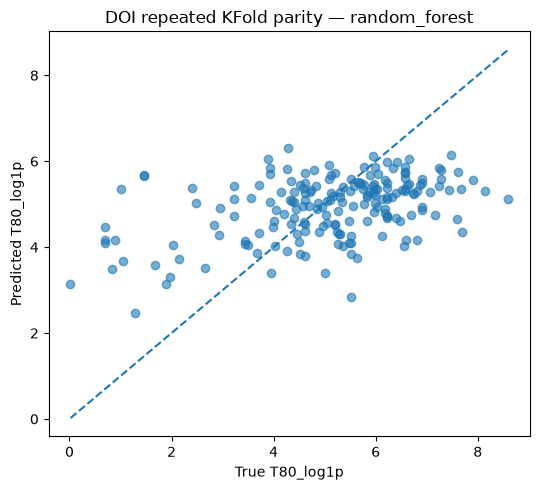

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06A_doi_regression\06A_doi_parity_random_forest.png


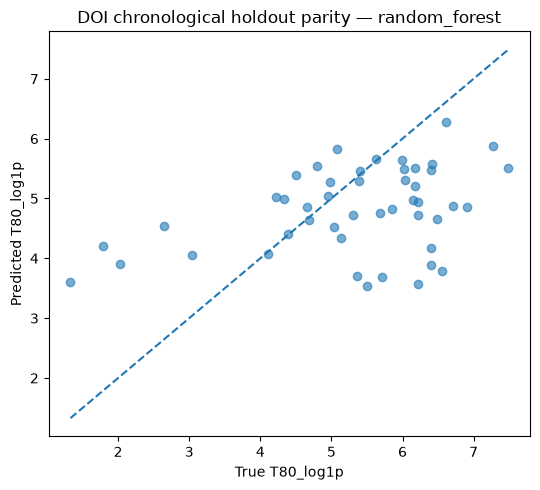

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06A_doi_regression\06A_doi_chrono_parity_random_forest.png


In [10]:
best_model_name = rkf_summary.iloc[0]["model"]
print("Best DOI regression model:", best_model_name)

parity_plot(
    rkf_examples[best_model_name]["y_true"],
    rkf_examples[best_model_name]["y_pred"],
    title=f"DOI repeated KFold parity — {best_model_name}",
    filename=f"06A_doi_parity_{best_model_name}.png"
)

if chrono_example is not None and best_model_name in chrono_example:
    parity_plot(
        chrono_example[best_model_name]["y_true"],
        chrono_example[best_model_name]["y_pred"],
        title=f"DOI chronological holdout parity — {best_model_name}",
        filename=f"06A_doi_chrono_parity_{best_model_name}.png"
    )
    

In [11]:
card = {
    "notebook": "06A_doi_level_regression.ipynb",
    "inputs": {
        "doi_table": DOI_TABLE_FILE,
        "doi_X": DOI_X_FILE,
        "doi_y": DOI_Y_FILE,
        "doi_groups": DOI_G_FILE,
    },
    "dataset_summary": {
        "n_rows": int(len(X)),
        "n_features": int(X.shape[1]),
        "n_unique_doi": int(groups.nunique()),
    },
    "validation": {
        "main": "RepeatedKFold on DOI rows",
        "secondary": "Chronological holdout if publication_year available"
    },
    "best_model": best_model_name
}

card_path = os.path.join(META_DIR, "06A_doi_regression_card.json")
with open(card_path, "w", encoding="utf-8") as f:
    json.dump(card, f, indent=4)

print("Saved:", card_path)
print("DONE.")

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\metadata\06A_doi_regression_card.json
DONE.


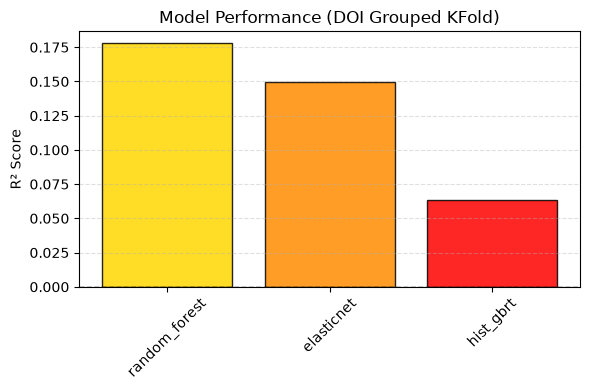

In [12]:
plt.figure(figsize=(6,4))

rkf_summary = rkf_summary.sort_values(by="r2_mean", ascending=False)

gradient_colors = ["gold", "darkorange", "red"]

bars = plt.bar(
    rkf_summary["model"],
    rkf_summary["r2_mean"],
    color=gradient_colors[:len(rkf_summary)],
    edgecolor="black",
    alpha=0.85
)

plt.ylabel("R² Score")
plt.title("Model Performance (DOI Grouped KFold)")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)


plt.axhline(0, color="black", linestyle="--", linewidth=1)


plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "model_performance.png"))
plt.show()

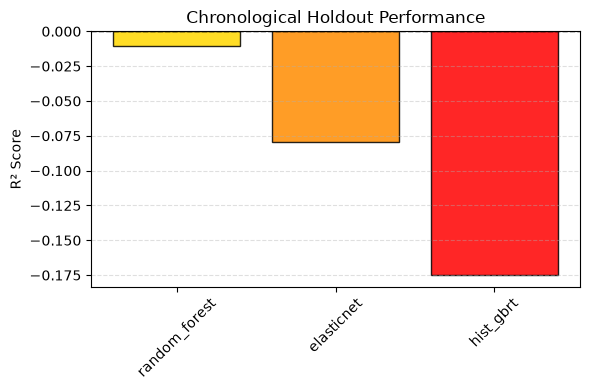

In [13]:
plt.figure(figsize=(6,4))

chrono_summary = chrono_summary.sort_values(by="r2", ascending=False)

gradient_colors = ["gold", "darkorange", "red"]

bars = plt.bar(
    chrono_summary["model"],
    chrono_summary["r2"],
    color=gradient_colors[:len(chrono_summary)],
    edgecolor="black",
    alpha=0.85
)

plt.ylabel("R² Score")
plt.title("Chronological Holdout Performance")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)


plt.axhline(0, color="black", linestyle="--", linewidth=1)


plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "chrono_performance.png"))
plt.show()

Best DOI regression model: random_forest
Best DOI CV R² from summary: 0.1777331036962046


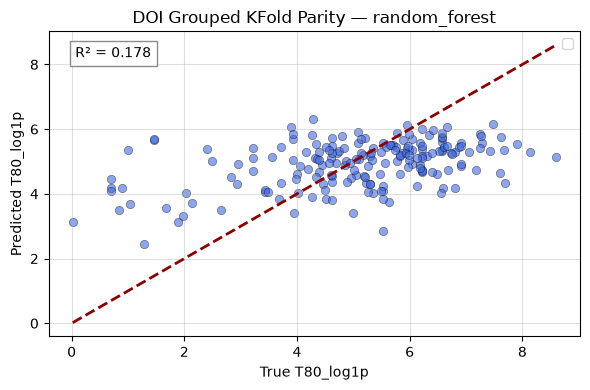

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06A_doi_regression\doi_parity_random_forest.png


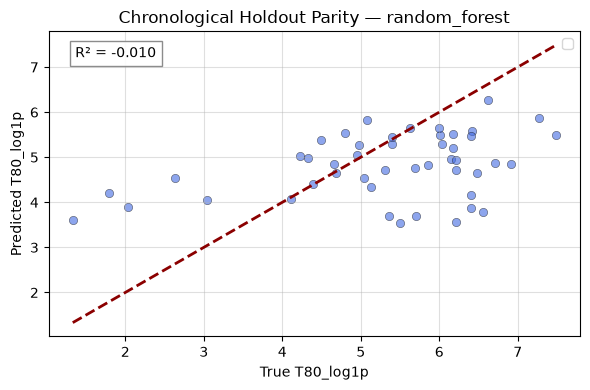

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06A_doi_regression\chrono_parity_random_forest.png


In [14]:
best_model_name = rkf_summary.iloc[0]["model"]
best_r2_cv = rkf_summary.iloc[0]["r2_mean"]

print("Best DOI regression model:", best_model_name)
print("Best DOI CV R² from summary:", best_r2_cv)


def parity_plot(y_true, y_pred, title, filename, artifact_dir, displayed_r2=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    plt.figure(figsize=(6, 4))

    plt.scatter(
        y_true,
        y_pred,
        alpha=0.6,
        edgecolors="black",
        linewidths=0.4,
        color="royalblue"
    )

    mn = min(float(np.min(y_true)), float(np.min(y_pred)))
    mx = max(float(np.max(y_true)), float(np.max(y_pred)))

    plt.plot(
        [mn, mx],
        [mn, mx],
        linestyle="--",
        linewidth=2,
        color="darkred",
    
    )

    plt.xlabel("True T80_log1p")
    plt.ylabel("Predicted T80_log1p")
    plt.title(title)
    plt.grid(alpha=0.4)

    if displayed_r2 is not None:
        r2_text = f"R² = {displayed_r2:.3f}"
    else:
        r2_text = f"R² = {r2_score(y_true, y_pred):.3f}"

    plt.text(
        0.05, 0.95,
        r2_text,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray")
    )

    plt.legend()
    plt.tight_layout()

    out = os.path.join(artifact_dir, filename)
    plt.savefig(out, dpi=600)
    plt.show()

    print("Saved:", out)

if best_model_name in rkf_examples:
    parity_plot(
        rkf_examples[best_model_name]["y_true"],
        rkf_examples[best_model_name]["y_pred"],
        title=f"DOI Grouped KFold Parity — {best_model_name}",
        filename=f"doi_parity_{best_model_name}.png",
        artifact_dir=ARTIFACT_DIR,
        displayed_r2=best_r2_cv
    )


if chrono_example is not None and best_model_name in chrono_example:
    chrono_r2 = chrono_summary.loc[
        chrono_summary["model"] == best_model_name, "r2"
    ].iloc[0]

    parity_plot(
        chrono_example[best_model_name]["y_true"],
        chrono_example[best_model_name]["y_pred"],
        title=f"Chronological Holdout Parity — {best_model_name}",
        filename=f"chrono_parity_{best_model_name}.png",
        artifact_dir=ARTIFACT_DIR,
        displayed_r2=chrono_r2
    )
else:
    print("Chronological example is not available for this model.")

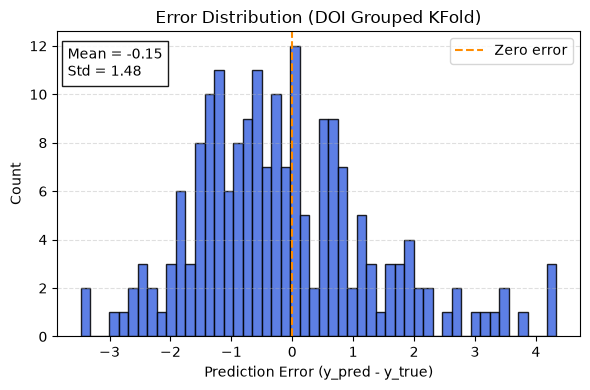

In [15]:
y_true = rkf_examples[best_model_name]["y_true"]
y_pred = rkf_examples[best_model_name]["y_pred"]

errors = y_pred - y_true

plt.figure(figsize=(6,4))

plt.axvline(0, color="darkorange", linestyle="--", linewidth=1.5, label="Zero error")
plt.hist(errors,bins=50,edgecolor="black",alpha=0.85,color="royalblue")
mean_err = np.mean(errors)
std_err = np.std(errors)

plt.xlabel("Prediction Error (y_pred - y_true)")
plt.ylabel("Count")
plt.title("Error Distribution (DOI Grouped KFold)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.text( 0.02, 0.95,f"Mean = {mean_err:.2f}\nStd = {std_err:.2f}", transform=plt.gca().transAxes, verticalalignment="top",bbox=dict(facecolor="white", alpha=0.9))
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "error_distribution.png"), dpi=600)
plt.show()

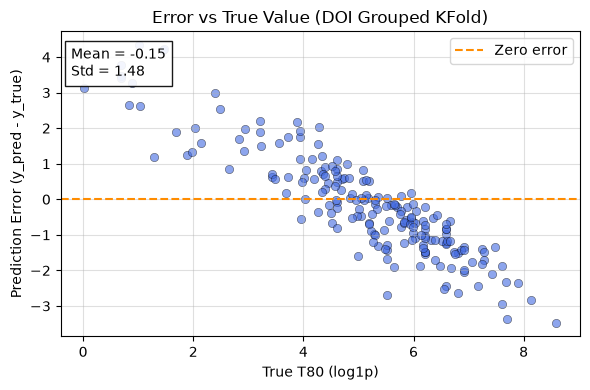

In [16]:
plt.figure(figsize=(6,4))


plt.scatter( y_true, errors, alpha=0.6, edgecolors="black",linewidths=0.4, color="royalblue")
plt.axhline(0, color="darkorange", linestyle="--", linewidth=1.5, label="Zero error")


mean_err = np.mean(errors)

plt.xlabel("True T80 (log1p)")
plt.ylabel("Prediction Error (y_pred - y_true)")
plt.title("Error vs True Value (DOI Grouped KFold)")
plt.text(0.02, 0.95,f"Mean = {mean_err:.2f}\nStd = {np.std(errors):.2f}",transform=plt.gca().transAxes,verticalalignment="top", bbox=dict(facecolor="white", alpha=0.9))

plt.grid(alpha=0.4)


plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "error_vs_true.png"), dpi=600)
plt.show()

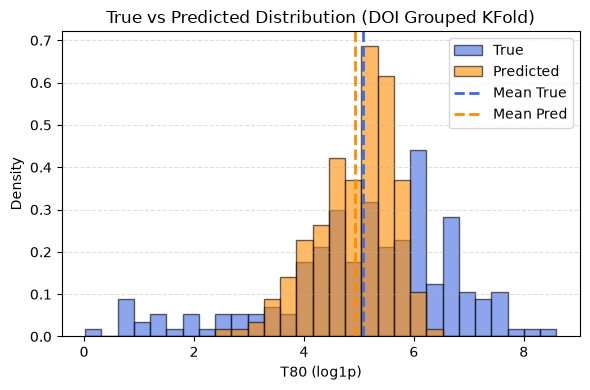

In [17]:
plt.figure(figsize=(6,4))

bins = np.linspace(
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max()),
    30
)

plt.hist( y_true,bins=bins,alpha=0.6,label="True",color="royalblue",edgecolor="black",density=True)

plt.hist( y_pred,bins=bins,alpha=0.6,label="Predicted",color="darkorange",edgecolor="black",density=True)

plt.axvline(np.mean(y_true), color="royalblue", linestyle="--", linewidth=2, label="Mean True")
plt.axvline(np.mean(y_pred), color="darkorange", linestyle="--", linewidth=2, label="Mean Pred")

plt.xlabel("T80 (log1p)")
plt.ylabel("Density")
plt.title("True vs Predicted Distribution (DOI Grouped KFold)")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "true_vs_pred_distribution.png"), dpi=600)
plt.show()

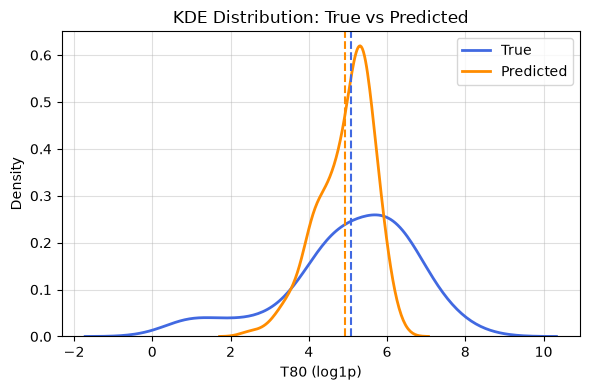

In [18]:
plt.figure(figsize=(6,4))

sns.kdeplot(y_true,label="True",color="royalblue", linewidth=2)
sns.kdeplot(y_pred,label="Predicted",color="darkorange",linewidth=2)

plt.axvline(np.mean(y_true), color="royalblue", linestyle="--", linewidth=1.5)
plt.axvline(np.mean(y_pred), color="darkorange", linestyle="--", linewidth=1.5)

plt.xlabel("T80 (log1p)")
plt.ylabel("Density")
plt.title("KDE Distribution: True vs Predicted")

plt.grid(alpha=0.4)
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "kde_true_vs_pred.png"), dpi=600)
plt.show()

In [19]:
print(rkf_summary.to_string(index=False))

            split         model  n_runs  r2_mean   r2_std  mae_mean  mae_std  medae_mean  medae_std  rmse_mean  rmse_std  n_test_mean  n_test_std
doi_grouped_kfold random_forest      50 0.177733 0.024326  1.236421 0.063688    0.980794   0.052242   1.576633  0.085361        192.8    0.404061
doi_grouped_kfold    elasticnet      50 0.149844 0.017155  1.236892 0.067215    0.988787   0.087852   1.603281  0.086633        192.8    0.404061
doi_grouped_kfold     hist_gbrt      50 0.063235 0.045388  1.315996 0.040340    1.082506   0.033235   1.680919  0.061373        192.8    0.404061
